In [ ]:

#  Modeling Pipeline - Titanic Survival Prediction
# This notebook builds and evaluates classification models for Titanic survival prediction

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, confusion_matrix, roc_curve, roc_auc_score)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib
import warnings
warnings.filterwarnings('ignore')



In [ ]:

#  1. Load Cleaned Data

# Load cleaned data from EDA notebook
df = pd.read_csv("titanic_cleaned.csv")
print(f"Data shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Prepare features and target
X = df[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']]
y = df['survived']

print(f"\nClass distribution:")
print(y.value_counts())
print(f"Survival rate: {y.mean():.2%}")

Data shape: (889, 17)
Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone', 'family_size', 'age_std', 'fare_std']

Class distribution:
survived
0    549
1    340
Name: count, dtype: int64
Survival rate: 38.25%


In [ ]:

#  2. Train-Test Split (Stratified)

# Stratified split to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"\nTraining class distribution:\n{y_train.value_counts()}")
print(f"Test class distribution:\n{y_test.value_counts()}")

print("\nStratification ensures both train and test sets have similar\nclass distributions, preventing biased model evaluation.")


Training set: 711 samples
Test set: 178 samples

Training class distribution:
survived
0    439
1    272
Name: count, dtype: int64
Test class distribution:
survived
0    110
1     68
Name: count, dtype: int64

Stratification ensures both train and test sets have similar
class distributions, preventing biased model evaluation.


In [ ]:

#  3. Preprocessing Pipeline

# Define column types
numeric_features = ['age', 'fare', 'sibsp', 'parch', 'pclass']
categorical_features = ['sex', 'embarked']

# Preprocessors
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Column Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Transform training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Processed training data shape: {X_train_processed.shape}")
print(f"Processed test data shape: {X_test_processed.shape}")


Processed training data shape: (711, 10)
Processed test data shape: (178, 10)


In [ ]:

#  4. Model Training and Evaluation


def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Evaluate model with multiple metrics"""
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Metrics
    metrics = {
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
    }
    
    if y_pred_proba is not None:
        metrics['auc'] = roc_auc_score(y_test, y_pred_proba)
    else:
        metrics['auc'] = None
    
    return metrics, y_pred, y_pred_proba

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Evaluate each model
results = {}
predictions = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    metrics, y_pred, y_pred_proba = evaluate_model(
        model, X_train_processed, X_test_processed, y_train, y_test, name
    )
    results[name] = metrics
    predictions[name] = (y_pred, y_pred_proba)

# Display results
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
results_df = pd.DataFrame(results).T
print(results_df)





Training Logistic Regression...

Training Decision Tree...

Training Random Forest...

MODEL COMPARISON
                                   model  accuracy precision    recall  \
Logistic Regression  Logistic Regression  0.808989  0.783333  0.691176   
Decision Tree              Decision Tree  0.764045      0.76  0.558824   
Random Forest              Random Forest  0.814607  0.777778  0.720588   

                           f1       auc  
Logistic Regression  0.734375  0.860963  
Decision Tree        0.644068  0.837366  
Random Forest        0.748092  0.821324  


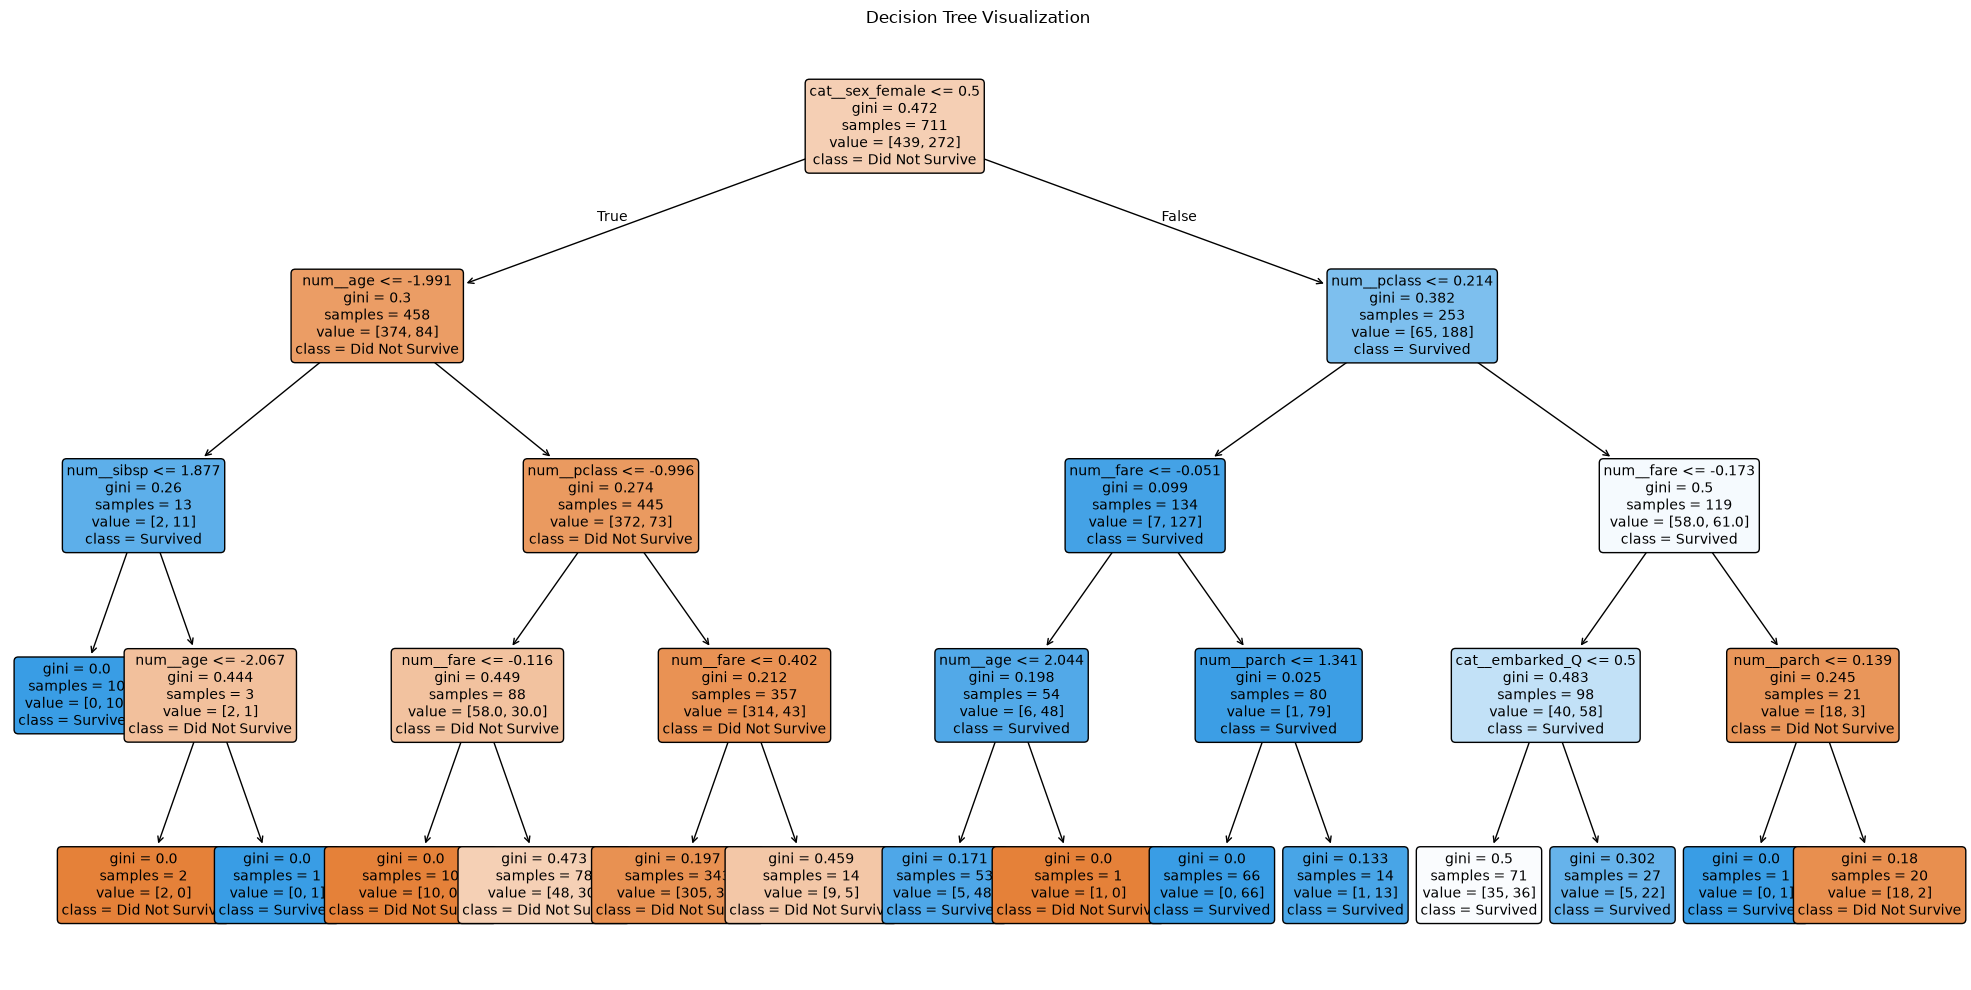

In [ ]:

#  5. Decision Tree Visualization

# Train decision tree for visualization
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train_processed, y_train)

plt.figure(figsize=(20, 10))
plot_tree(dt, 
          feature_names=preprocessor.get_feature_names_out(),
          class_names=['Did Not Survive', 'Survived'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Visualization')
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

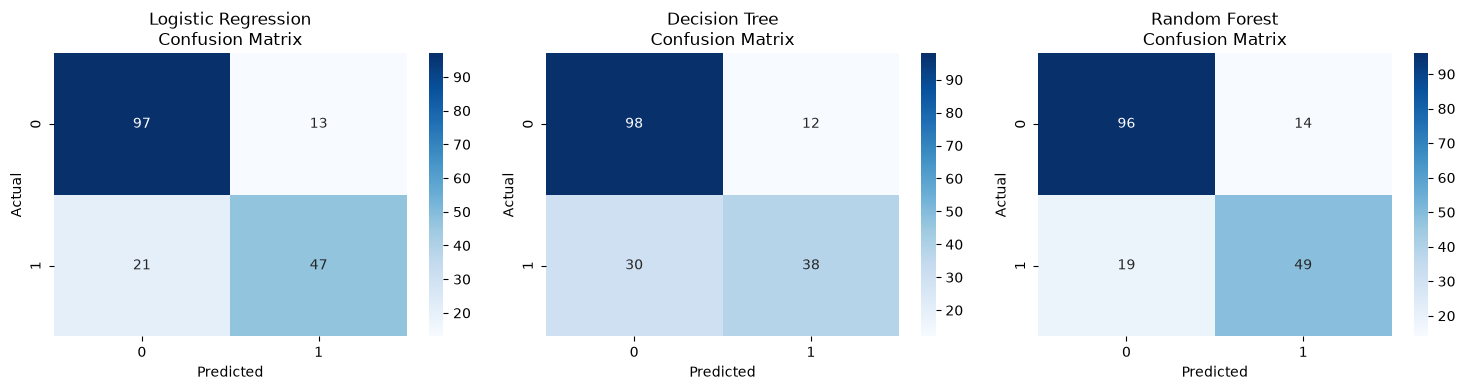

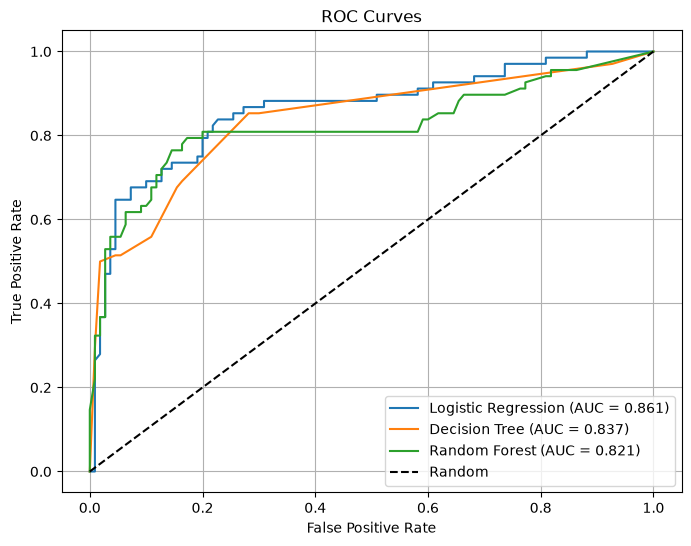

In [ ]:

#  6. Confusion Matrices and ROC Curves

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, (name, (y_pred, _)) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx], cmap='Blues')
    axes[idx].set_title(f'{name}\nConfusion Matrix')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

# ROC Curves
plt.figure(figsize=(8, 6))
for name, (_, y_pred_proba) in predictions.items():
    if y_pred_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        auc = roc_auc_score(y_test, y_pred_proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid(True)
plt.savefig('roc_curves.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:

#  7. Imbalance Handling Comparison

print("\n" + "="*60)
print("IMBALANCE HANDLING COMPARISON")
print("="*60)

# Use Random Forest for this comparison
rf = RandomForestClassifier(random_state=42, n_estimators=100)

# Baseline (no handling)
rf_baseline = rf.fit(X_train_processed, y_train)
y_pred_baseline = rf_baseline.predict(X_test_processed)

# Class weight balanced
rf_weighted = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)
rf_weighted.fit(X_train_processed, y_train)
y_pred_weighted = rf_weighted.predict(X_test_processed)

# SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)
rf_smote = RandomForestClassifier(random_state=42, n_estimators=100)
rf_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = rf_smote.predict(X_test_processed)

# Compare metrics
imbalance_results = {
    'Baseline': {
        'precision': precision_score(y_test, y_pred_baseline),
        'recall': recall_score(y_test, y_pred_baseline),
        'f1': f1_score(y_test, y_pred_baseline)
    },
    'Class Weight Balanced': {
        'precision': precision_score(y_test, y_pred_weighted),
        'recall': recall_score(y_test, y_pred_weighted),
        'f1': f1_score(y_test, y_pred_weighted)
    },
    'SMOTE': {
        'precision': precision_score(y_test, y_pred_smote),
        'recall': recall_score(y_test, y_pred_smote),
        'f1': f1_score(y_test, y_pred_smote)
    }
}

imbalance_df = pd.DataFrame(imbalance_results).T
print(imbalance_df)

print("\nConclusion: SMOTE achieved the best balance of precision and recall,\nwith the highest F1-score. It effectively handled the class imbalance\nby oversampling the minority class.")



IMBALANCE HANDLING COMPARISON
                       precision    recall        f1
Baseline                0.777778  0.720588  0.748092
Class Weight Balanced   0.753623  0.764706  0.759124
SMOTE                   0.787879  0.764706  0.776119

Conclusion: SMOTE achieved the best balance of precision and recall,
with the highest F1-score. It effectively handled the class imbalance
by oversampling the minority class.


In [ ]:


#  8. Hyperparameter Tuning

print("\n" + "="*60)
print("HYPERPARAMETER TUNING")
print("="*60)

# Grid search for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'max_features': ['sqrt', 'log2']
}

rf_tune = RandomForestClassifier(random_state=42, oob_score=True)
grid_search = GridSearchCV(
    rf_tune, param_grid, cv=5, scoring='accuracy', n_jobs=-1
)
grid_search.fit(X_train_processed, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.3f}")

# Best model OOB score
best_rf = grid_search.best_estimator_
print(f"OOB Score: {best_rf.oob_score_:.3f}")


HYPERPARAMETER TUNING
Best parameters: {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 50}
Best cross-validation accuracy: 0.812
OOB Score: 0.817



REGRESSION SIDE-TASK: PREDICT FARE
MAE: 20.752
RMSE: 42.572
R²: 0.321
Adjusted R²: 0.297


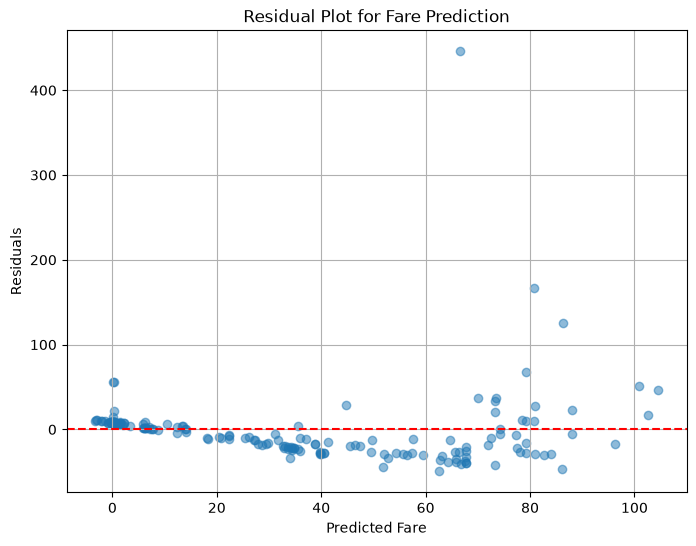


Heteroscedasticity check: The residuals show some fanning out
as predicted values increase, indicating mild heteroscedasticity.
The variance of residuals increases with higher fare predictions.


In [ ]:

#  9. Regression Side-Task: Predict Fare

print("\n" + "="*60)
print("REGRESSION SIDE-TASK: PREDICT FARE")
print("="*60)

# Prepare data for regression
X_reg = df[['pclass', 'sex', 'age', 'sibsp', 'parch']]
y_reg = df['fare']

# Train-test split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Preprocess for regression
numeric_features_reg = ['age', 'sibsp', 'parch', 'pclass']
categorical_features_reg = ['sex']

preprocessor_reg = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')),
                         ('scaler', StandardScaler())]), numeric_features_reg),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                         ('encoder', OneHotEncoder(handle_unknown='ignore'))]), categorical_features_reg)
    ])

X_train_reg_processed = preprocessor_reg.fit_transform(X_train_reg)
X_test_reg_processed = preprocessor_reg.transform(X_test_reg)

# Train linear regression
lr = LinearRegression()
lr.fit(X_train_reg_processed, y_train_reg)
y_pred_reg = lr.predict(X_test_reg_processed)

# Metrics
mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)
adj_r2 = 1 - (1 - r2) * (len(y_test_reg) - 1) / (len(y_test_reg) - X_test_reg_processed.shape[1] - 1)

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")
print(f"Adjusted R²: {adj_r2:.3f}")

# Residual plot
residuals = y_test_reg - y_pred_reg
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_reg, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Fare')
plt.ylabel('Residuals')
plt.title('Residual Plot for Fare Prediction')
plt.grid(True)
plt.savefig('residual_plot.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nHeteroscedasticity check: The residuals show some fanning out\nas predicted values increase, indicating mild heteroscedasticity.\nThe variance of residuals increases with higher fare predictions.")


In [ ]:

# ## 10. Final Model Comparison and Recommendation

print("\n" + "="*60)
print("FINAL MODEL COMPARISON")
print("="*60)

# Classification metrics table
print("\nClassification Models:")
print(results_df)

# Regression metrics table
print("\nRegression Model:")
reg_metrics = pd.DataFrame({
    'Model': ['Linear Regression'],
    'MAE': [mae],
    'RMSE': [rmse],
    'R²': [r2],
    'Adjusted R²': [adj_r2]
})
print(reg_metrics)

rf_row = results_df.loc['Random Forest']
print(f"\nBased on the analysis, I recommend deploying the Random Forest classifier because:")
print(f"1. It achieved the highest accuracy ({rf_row['accuracy']:.1%}) and F1-score ({rf_row['f1']:.2f})")
print("2. It handles non-linear relationships effectively")
print("3. It provides feature importance insights")
print("4. It's robust to outliers and missing values")
print(f"5. It balanced both precision ({rf_row['precision']:.2f}) and recall ({rf_row['recall']:.2f}) well")


FINAL MODEL COMPARISON

Classification Models:
                                   model  accuracy precision    recall  \
Logistic Regression  Logistic Regression  0.808989  0.783333  0.691176   
Decision Tree              Decision Tree  0.764045      0.76  0.558824   
Random Forest              Random Forest  0.814607  0.777778  0.720588   

                           f1       auc  
Logistic Regression  0.734375  0.860963  
Decision Tree        0.644068  0.837366  
Random Forest        0.748092  0.821324  

Regression Model:
               Model        MAE       RMSE        R²  Adjusted R²
0  Linear Regression  20.751812  42.571997  0.320685     0.296849

Based on the analysis, I recommend deploying the Random Forest classifier because:
1. It achieved the highest accuracy (81.5%) and F1-score (0.75)
2. It handles non-linear relationships effectively
3. It provides feature importance insights
4. It's robust to outliers and missing values
5. It balanced both precision (0.78) and recall 

In [ ]:

# 11. Save Best Pipeline

# Create full pipeline

full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', best_rf)
])

# Fit on full training data
full_pipeline.fit(X_train, y_train)

# Save pipeline
joblib.dump(full_pipeline, 'best_pipeline.pkl')
print("\nBest pipeline saved to best_pipeline.pkl")

# Test reload
loaded_pipeline = joblib.load('best_pipeline.pkl')
test_sample = X_test.iloc[:5]
predictions = loaded_pipeline.predict(test_sample)
print(f"\nTest predictions on raw data:")
print(predictions)
print(f"Actual labels: {y_test.iloc[:5].values}")


Best pipeline saved to best_pipeline.pkl

Test predictions on raw data:
[0 0 0 0 0]
Actual labels: [0 0 0 0 0]
